In [1]:
import pandas as pd

### Loading Datasets

In [2]:
customers_dataset_df = pd.read_csv("../data/olist_customers_dataset.csv")
orders_dataset_df = pd.read_csv("../data/olist_orders_dataset.csv")
order_items_dataset_df = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments_dataset_df = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews_dataset_df = pd.read_csv("../data/olist_order_reviews_dataset.csv")
sellers_dataset_df = pd.read_csv("../data/olist_sellers_dataset.csv")
products_dataset_df = pd.read_csv("../data/olist_products_dataset.csv")
geolocation_dataset_df = pd.read_csv("../data/olist_geolocation_dataset.csv")
products_name_translation_df = pd.read_csv("../data/product_category_name_translation.csv")


### Merging DataSets with Relationships

In [3]:
# orders_dataset_df
# order_items_dataset_df.describe()

main_df = orders_dataset_df.merge(order_items_dataset_df, on='order_id', how='left')
# main_df.describe(include='str')
main_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value'],
      dtype='str')

In [4]:
products_dataset_df.columns
# main_df.info()
main_df = main_df.merge(products_dataset_df, on='product_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  str    
 10  seller_id                      112650 non-null  str    
 11  shipping_limit_date            112650 non-null  str    
 12  price                          112650 non

In [5]:
# Merging Sellers Dataset
sellers_dataset_df.info()
sellers_dataset_df['seller_id'].duplicated().sum()
sellers_dataset_df['seller_id'].isnull().sum()
main_df = main_df.merge(sellers_dataset_df, on='seller_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carr

In [6]:
# Merging payments_dataset
order_payments_dataset_df.info()
# We want to agg and merge otherwise we get more duplicate rows and messy data
order_payments_dataset_df['order_id'].duplicated().sum()

# Creating Payment List for looping
payment_types = [
    'credit_card',
    'boleto',
    'voucher',
    'debit_card',
    'not_defined'
]

# Creating colunms
for payment in payment_types:
    order_payments_dataset_df[f'used_{payment}'] = (order_payments_dataset_df['payment_type'] == payment).astype(int)
    
payment_summary = order_payments_dataset_df.groupby('order_id').agg(payment_type_count=('payment_type', 'count'), 
                                                      used_credit_card=('used_credit_card', 'max'), 
                                                      used_boleto=('used_boleto', 'max'), 
                                                      used_voucher=('used_voucher', 'max'), 
                                                      used_debit_card=('used_debit_card', 'max'), 
                                                      used_not_defined=('used_not_defined', 'max'),
                                                      total_payment_value=('payment_value', 'sum')).reset_index()

payment_summary.shape

main_df = main_df.merge(payment_summary, on='order_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_ap

In [7]:
# Before Merging we want to analyze
customers_dataset_df.info()
# Checking unique rows equals info() rows 
customers_dataset_df['customer_id'].unique()
# If unique rows are equal means no duplicates (even checked)
customers_dataset_df.duplicated().sum()
#Checking missing values
customers_dataset_df.isnull().sum()
#Merging with main_df
main_df = main_df.merge(customers_dataset_df, on='customer_id', how='left')
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_

In [8]:
# Products_name_translatio n_merging
products_name_translation_df.info()
products_name_translation_df['product_category_name'].duplicated().sum()

main_df = main_df.merge(products_name_translation_df, on='product_category_name', how='left')
main_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  

### Analyzing missing values and duplicates in Main dataset


In [9]:
# Missing Values
main_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
seller_zip_code_prefix            775
seller_city                       775
seller_state                      775
payment_type_count                  3
used_credit_

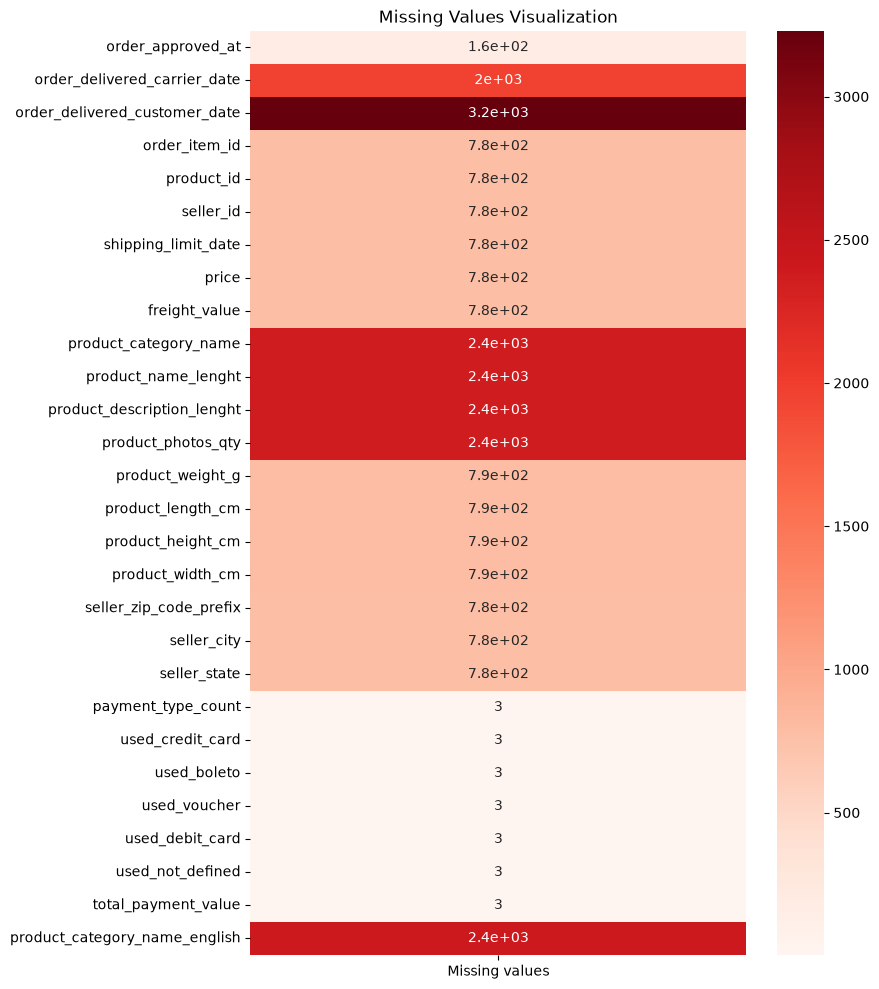

In [10]:
# Visulaizing Missing values
import matplotlib.pyplot as plt
import seaborn as sns

missing_value = main_df.isnull().sum().loc[lambda x: x > 0]
missing_value = pd.DataFrame(missing_value, columns=['Missing values'])
plt.figure(figsize=(8, 12))
sns.heatmap(missing_value, cmap="Reds",annot=True)
plt.title("Missing Values Visualization")
plt.show()

In [11]:
main_df.duplicated().sum()

np.int64(0)

In [12]:
# Dimensions
print("Main_dataset : \n(Rows, columns)\n", main_df.shape)

Main_dataset : 
(Rows, columns)
 (113425, 37)


In [13]:
# Descriptive Stats for numerical features
main_df.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_type_count,used_credit_card,used_boleto,used_voucher,used_debit_card,used_not_defined,total_payment_value,customer_zip_code_prefix
count,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,112650.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113425.000000
mean,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546,24439.170431,1.044163,0.766597,0.203109,0.037409,0.014962,0.000026,180.482857,35102.472965
std,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268,27596.030909,0.386006,0.422998,0.402315,0.189763,0.121401,0.005143,273.548227,29864.919733
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1003.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,65.680000,11250.000000
50%,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13568.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,114.400000,24320.000000
75%,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27930.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,195.360000,59020.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13664.080000,99990.000000


In [14]:
# Descriptive Stats for categorical features
main_df.describe(include='str')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,shipping_limit_date,product_category_name,seller_city,seller_state,customer_unique_id,customer_city,customer_state,product_category_name_english
count,113425,113425,113425,113425,113264,111457,110196,113425,112650,112650,112650,111047,112650,112650,113425,113425,113425,111023
unique,99441,99441,8,98875,90733,81018,95664,459,32951,3095,93318,73,611,23,96096,4119,27,71
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2018-02-24 03:20:27,2018-05-09 15:48:00,2017-07-31 18:03:02,2017-12-20 00:00:00,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,cama_mesa_banho,sao paulo,SP,c8460e4251689ba205045f3ea17884a1,sao paulo,SP,bed_bath_table
freq,21,21,110197,21,23,48,21,611,527,2033,21,11115,27983,80342,24,17946,47820,11115


In [15]:
# Creating Dataset 
main_df.to_csv("../data/main_dataset.csv", index=False)